# 03 · Cleanup tuning — killing ring artefacts

**Audience:** anyone whose reconstruction shows concentric ring artefacts
around the rotation axis. Almost every real synchrotron tomo scan has
them at some level, caused by miscalibrated / dead / fluctuating
detector pixels.

**Tools:** the new `run_tomo_cleanup_sweep()` Python API and the
`--tuneCleanup` flag on `process_hdf.py`. Both wrap the new C-level
`stripeConfigFile` keyword that sweeps Vo et al. (2018) parameters in
one MIDAS_TOMO invocation.

**Strategy:** tune on a thin slab (4 slices, single shift, runs in
seconds), pick the best config visually + by a numeric ring metric,
then commit to that config for the full sweep.


In [1]:
# --- Setup ---------------------------------------------------------
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make the MIDAS TOMO Python API importable
MIDAS_TOMO = os.path.expanduser('~/opt/MIDAS/TOMO')
if MIDAS_TOMO not in sys.path:
    sys.path.insert(0, MIDAS_TOMO)
NB_DIR = os.path.join(MIDAS_TOMO, 'notebooks')
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

import _phantom as phantom

# Working directory for this notebook's outputs
WORK = os.path.expanduser('~/tomo_notebooks/03_cleanup')
os.makedirs(WORK, exist_ok=True)
print('Working dir:', WORK)


Working dir: /Users/hsharma/tomo_notebooks/03_cleanup


## 1 · Make synthetic data with intentional ring sources

The phantom helper adds a handful of dead and flicker detector columns
on top of the projections. Those become rings in any reconstruction
that doesn't compensate for them.


In [2]:
vol = phantom.make_phantom(64, 64, 64)
angles = np.arange(0, 180, 1.0, dtype=np.float32)
acq = phantom.make_acquisition(vol, angles, add_rings=True)
print('Ring-source columns injected at x =',
      sorted(acq.ring_columns.tolist()))
whites = np.stack([acq.whites_before.mean(0), acq.whites_after.mean(0)])


Ring-source columns injected at x = [12, 28, 34]


## 2 · Baseline reconstruction — see the problem

With **no** stripe removal, the dead/flicker columns paint visible rings
centered on the rotation axis.


In [3]:
from midas_tomo_python import run_tomo

recon_baseline = run_tomo(acq.projections, acq.dark, whites,
                          WORK, angles, shifts=0.0, numCPUs=4,
                          doCleanup=0)
cube = recon_baseline[0]
print('cube:', cube.shape)


Time elapsed in preprocessing: 0.002s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/03_cleanup/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/03_cleanup/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1573050, Total available RAM: 68719476736, MaxNProcs: 43685.
We can run up to 43683 processes.
We w

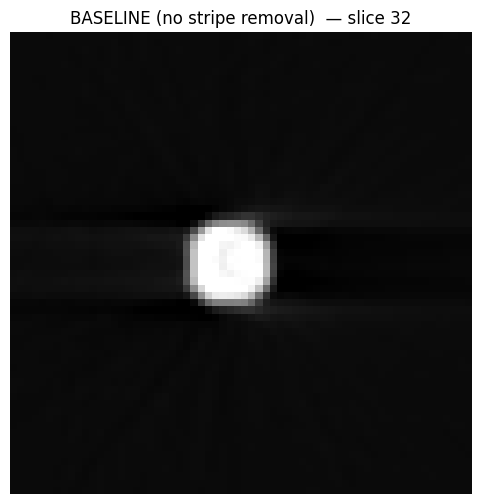

In [4]:
sl = cube.shape[0] // 2
plt.figure(figsize=(6, 6))
vmin, vmax = np.percentile(cube[sl], 1), np.percentile(cube[sl], 99)
plt.imshow(cube[sl], cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f'BASELINE (no stripe removal)  — slice {sl}')
plt.axis('off'); plt.show()


## 3 · The built-in cleanup grid

`default_cleanup_grid(detector_xdim)` scales four sensible configurations
to the detector width:

- `(0, 0, 0)`            — the no-cleanup baseline (always include
                           this — it anchors the comparison)
- `(snr=3.0, la=w/4, sm=w/12)` — moderate
- `(snr=3.0, la=w/3, sm=w/9)`  — broader stripes
- `(snr=1.5, la=w/4, sm=w/12)` — aggressive SNR (catches fainter stripes)

For a 64-px-wide detector this gives:


In [5]:
from midas_tomo_python import default_cleanup_grid
grid = default_cleanup_grid(acq.projections.shape[2])
print(grid)


[{'snr': 0.0, 'la': 0, 'sm': 0}, {'snr': 3.0, 'la': 17, 'sm': 5}, {'snr': 3.0, 'la': 21, 'sm': 7}, {'snr': 1.5, 'la': 17, 'sm': 5}]


## 4 · Run the sweep on a 4-slice slab

The sweep emits one reconstruction per cleanup config. We pick a small
set of mid-stack slices so this finishes in well under a second.

Outputs land in `WORK/cleanup_tuning_*`:

- `cleanup_tuning_montage.png`     — visual side-by-side comparison
- `cleanup_tuning_scores.txt`      — per-config ring metric
- `cleanup_tuning_recommended.txt` — one line: `snr la sm` (the pick)


In [6]:
from midas_tomo_python import run_tomo_cleanup_sweep

result = run_tomo_cleanup_sweep(
    acq.projections, acq.dark, whites,
    WORK, angles,
    shift=0.0,            # known optimal shift for the phantom
    cleanup_configs=None, # None → built-in grid
    numCPUs=4, doCleanup=0,
)
print('\nBest config:', result['best_config'])
print('Configs and ring metrics:')
for ci, (c, rm) in enumerate(zip(result['configs'], result['ring_metric'])):
    mark = '  <-- BEST' if ci == result['best_idx'] else ''
    print(f'  #{ci}  snr={c["snr"]:5.2f}  la={c["la"]:3d}  sm={c["sm"]:3d}'
          f'  ring={rm:.3e}{mark}')


Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are reading the slices file: /Users/hsharma/tomo_notebooks/03_cleanup/cleanup_tuning_slices.txt.

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/03_cleanup/cleanup_tuning_input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/03_cleanup/cleanup_tuning_output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.10 (step 0.10, n=2)
    Slices          : 4
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes SWEEP over 4 configs (file: /Users/hsharma/tomo_notebooks/03_cleanup/cleanup_tuning_grid.txt)

  Cleanup configurations:
    idx     snr    la_size   sm_size
   

Saved /Users/hsharma/tomo_notebooks/03_cleanup/cleanup_tuning_montage.png

Best config: {'snr': 1.5, 'la': 17, 'sm': 5}
Configs and ring metrics:
  #0  snr= 0.00  la=  0  sm=  0  ring=1.072e-02
  #1  snr= 3.00  la= 17  sm=  5  ring=3.462e-03
  #2  snr= 3.00  la= 21  sm=  7  ring=2.363e-04
  #3  snr= 1.50  la= 17  sm=  5  ring=2.378e-05  <-- BEST


## 5 · View the comparison montage

The montage shows the middle tuning slice for every cleanup config,
with the auto-pick highlighted in red. The ring metric (lower is
cleaner) appears in each panel.


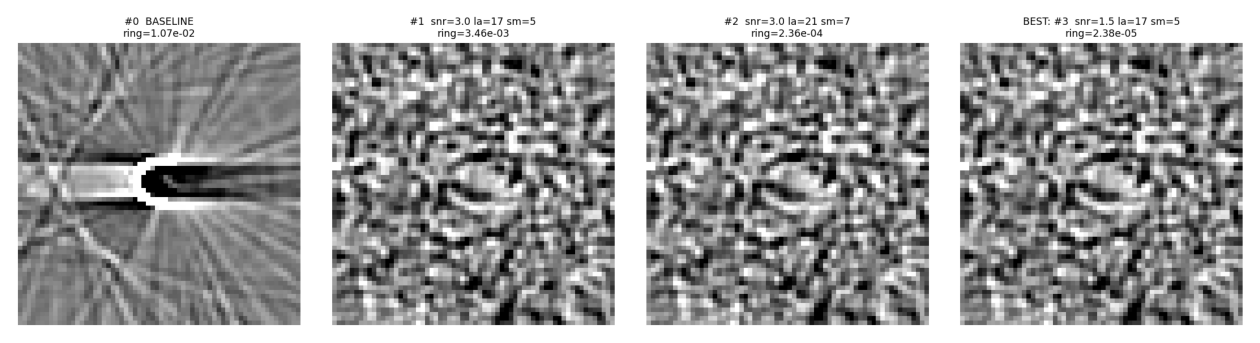

In [7]:
from PIL import Image
montage = os.path.join(WORK, 'cleanup_tuning_montage.png')
plt.figure(figsize=(16, 5))
plt.imshow(np.array(Image.open(montage)))
plt.axis('off'); plt.show()


## 6 · Override the auto-pick (if you want a custom grid)

Auto-picking by ring metric works most of the time, but on samples
whose real features happen to be ring-shaped (rings in a coin cell,
membranes, capillaries) the metric can over-penalize them. When in
doubt, write your own grid and pick visually.


In [8]:
custom_grid = [
    {'snr': 0.0, 'la': 0,  'sm': 0},   # baseline
    {'snr': 3.0, 'la': 15, 'sm': 5},   # narrow windows
    {'snr': 3.0, 'la': 25, 'sm': 9},
    {'snr': 1.5, 'la': 25, 'sm': 9},   # more sensitive
    {'snr': 1.5, 'la': 35, 'sm': 13},  # most aggressive
]

result2 = run_tomo_cleanup_sweep(
    acq.projections, acq.dark, whites,
    os.path.join(WORK, 'custom'), angles,
    shift=0.0, cleanup_configs=custom_grid,
    numCPUs=4, doCleanup=0,
)
for ci, (c, rm) in enumerate(zip(result2['configs'], result2['ring_metric'])):
    mark = '  <-- BEST' if ci == result2['best_idx'] else ''
    print(f'  #{ci}  snr={c["snr"]:5.2f}  la={c["la"]:3d}  sm={c["sm"]:3d}'
          f'  ring={rm:.3e}{mark}')


Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are reading the slices file: /Users/hsharma/tomo_notebooks/03_cleanup/custom/cleanup_tuning_slices.txt.

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/03_cleanup/custom/cleanup_tuning_input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/03_cleanup/custom/cleanup_tuning_output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.10 (step 0.10, n=2)
    Slices          : 4
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes SWEEP over 5 configs (file: /Users/hsharma/tomo_notebooks/03_cleanup/custom/cleanup_tuning_grid.txt)

  Cleanup configurations:
    idx     

Saved /Users/hsharma/tomo_notebooks/03_cleanup/custom/cleanup_tuning_montage.png
  #0  snr= 0.00  la=  0  sm=  0  ring=1.072e-02
  #1  snr= 3.00  la= 15  sm=  5  ring=7.269e-03
  #2  snr= 3.00  la= 25  sm=  9  ring=3.326e-05
  #3  snr= 1.50  la= 25  sm=  9  ring=2.472e-05
  #4  snr= 1.50  la= 35  sm= 13  ring=2.383e-05  <-- BEST


## 7 · Apply the picked config to the full reconstruction

Now use the recommended `(snr, la, sm)` on the full slice stack.


In [9]:
bc = result['best_config']
if bc['snr'] > 0:
    recon_cleaned = run_tomo(
        acq.projections, acq.dark, whites,
        WORK, angles, shifts=0.0, numCPUs=4, doCleanup=0,
        doStripeRemoval=1, stripeSnr=bc['snr'],
        stripeLaSize=bc['la'], stripeSmSize=bc['sm'],
    )
else:
    recon_cleaned = recon_baseline
cube_cleaned = recon_cleaned[0]


Time elapsed in preprocessing: 0.002s.


Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/03_cleanup/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/03_cleanup/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : Yes (snr=1.5, la=17, sm=5)

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1573050, Total available RAM: 68719476736, MaxNProcs: 43685.
We can run up to 43683 processes.
We will use 6 MB RA

## 8 · Before vs after


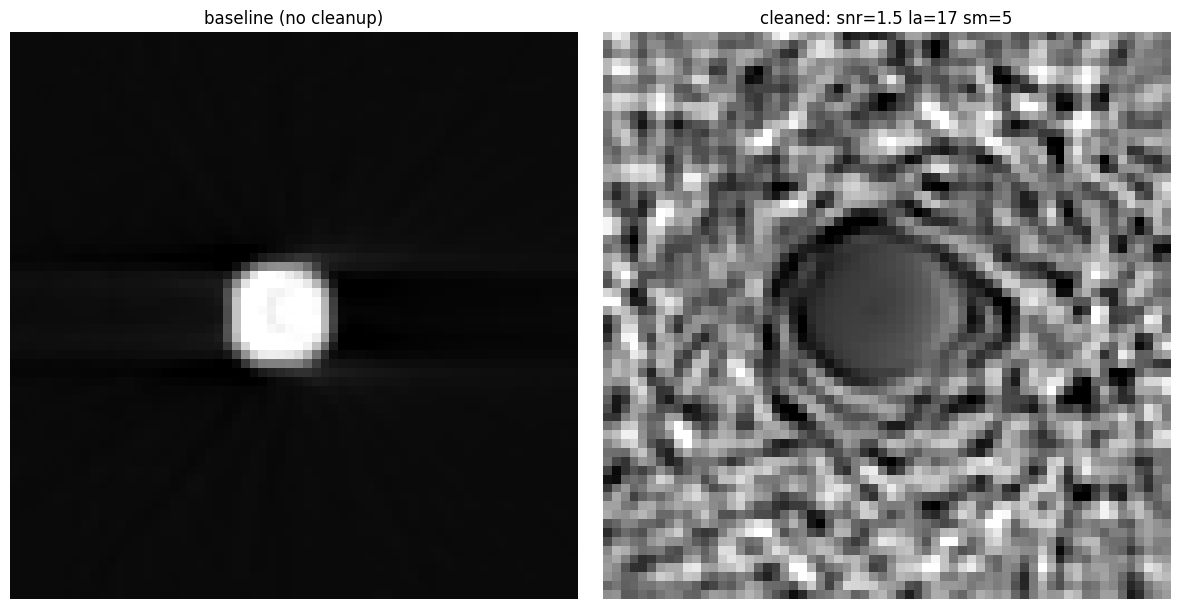

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, im, t in zip(ax, [cube[sl], cube_cleaned[sl]],
                    ['baseline (no cleanup)',
                     f'cleaned: snr={bc["snr"]} la={bc["la"]} sm={bc["sm"]}']):
    vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
    a.imshow(im, cmap='gray', vmin=vmin, vmax=vmax)
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 9 · The same thing from the CLI

The exact same workflow is available without writing any Python:

```bash
python ~/opt/MIDAS/TOMO/process_hdf.py -dataFN data.h5 -nCPUs 20 \
    --tuneCleanup
```

With no argument to `--tuneCleanup`, the built-in grid is used. To use
your own grid file:

```bash
python ~/opt/MIDAS/TOMO/process_hdf.py -dataFN data.h5 -nCPUs 20 \
    --tuneCleanup my_grid.txt
```

Where `my_grid.txt` is one `snr la sm` per line (`#` comments
allowed). Or skip tuning and force a config:

```bash
python ~/opt/MIDAS/TOMO/process_hdf.py -dataFN data.h5 -nCPUs 20 \
    --cleanup 3.0 31 11
```

See `manuals/Tomography_Reconstruction.md` §4.3 for the C-level
`stripeConfigFile` keyword that all of these wrap.


## 10 · Next steps

- **[04_shift_search.ipynb](04_shift_search.ipynb)** — combine
  cleanup tuning with rotation-axis search.
- **[06_troubleshooting.ipynb](06_troubleshooting.ipynb)** has a
  section on what to do when cleanup tuning picks the baseline
  (usually that means rings are already weak or your metric is
  mistaking real structure for stripes).
